In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
# https://www.kaggle.com/datasets/nsrose7224/crowdedness-at-the-campus-gym

In [3]:
df = pd.read_csv('data.csv')

In [4]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [5]:
df.shape

(62184, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [7]:
df.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [8]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [9]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [10]:
df['date'] = pd.to_datetime(df['date'], utc=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [12]:
df['date']

0       2015-08-15 00:00:11+00:00
1       2015-08-15 00:20:14+00:00
2       2015-08-15 00:30:15+00:00
3       2015-08-15 00:40:16+00:00
4       2015-08-15 00:50:17+00:00
                   ...           
62179   2017-03-19 01:42:28+00:00
62180   2017-03-19 01:52:35+00:00
62181   2017-03-19 02:02:40+00:00
62182   2017-03-19 02:12:47+00:00
62183   2017-03-19 02:22:51+00:00
Name: date, Length: 62184, dtype: datetime64[ns, UTC]

In [13]:
df['date'].dt.month # year,month,hour hepsini bu şekilde getirebiliyoruz datetime objesi sayesinde

0        8
1        8
2        8
3        8
4        8
        ..
62179    3
62180    3
62181    3
62182    3
62183    3
Name: date, Length: 62184, dtype: int32

In [14]:
# datasette gün ay ve saat kolonu var. Date kolonundan sadece yılı çekip year kolonu oluşturabiliriz

df['year'] = df['date'].dt.year
# df['month'] = df['date'].dt.month
# df['hour'] = df['date'].dt.hour
# df['day'] = df['date'].dt.day

In [15]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17,2015


In [16]:
df['year'].unique()

array([2015, 2016, 2017], dtype=int32)

In [17]:
df.drop('date', axis=1, inplace=True)

In [18]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


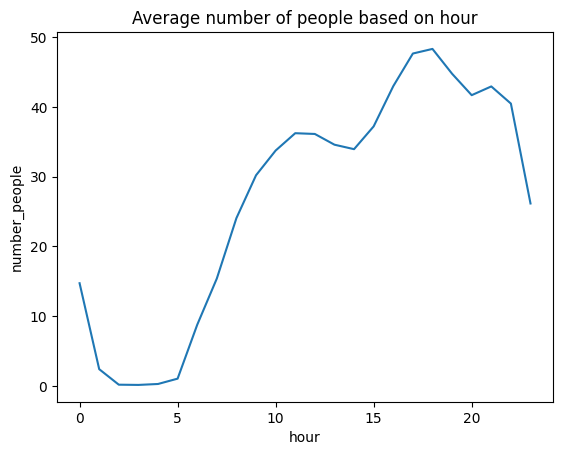

In [19]:
sns.lineplot(data=df, x="hour", y="number_people", errorbar=None)
plt.title("Average number of people based on hour")
plt.show()

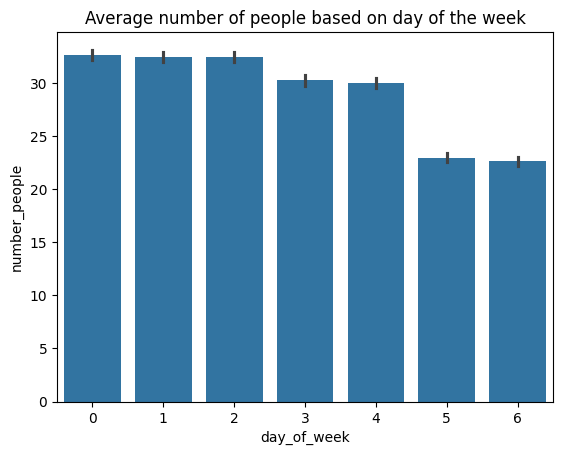

In [20]:
sns.barplot(data=df, x="day_of_week", y="number_people")
plt.title("Average number of people based on day of the week")
plt.show()

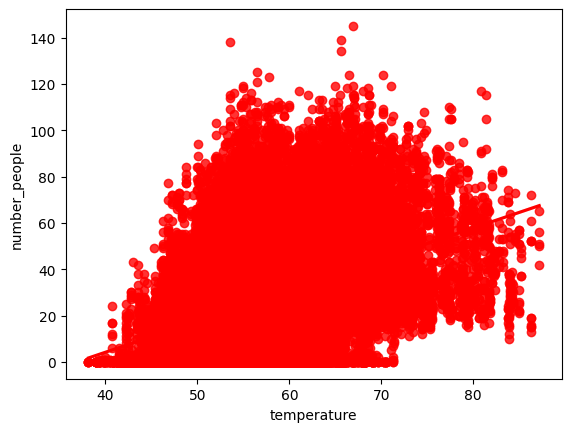

In [21]:
sns.regplot(data=df, x="temperature", y="number_people", color="r")
plt.show()

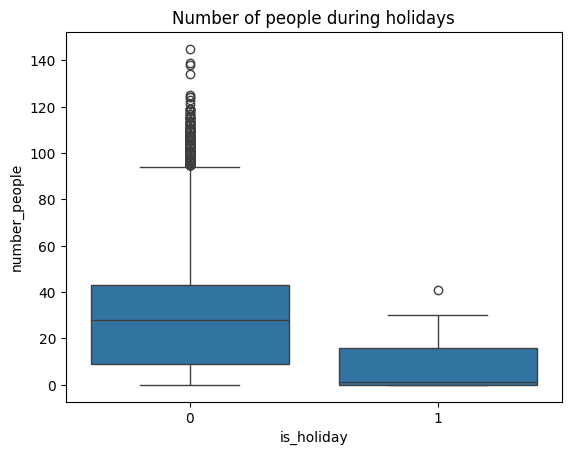

In [22]:
sns.boxplot(data=df, x="is_holiday", y="number_people")
plt.title("Number of people during holidays")
plt.show()

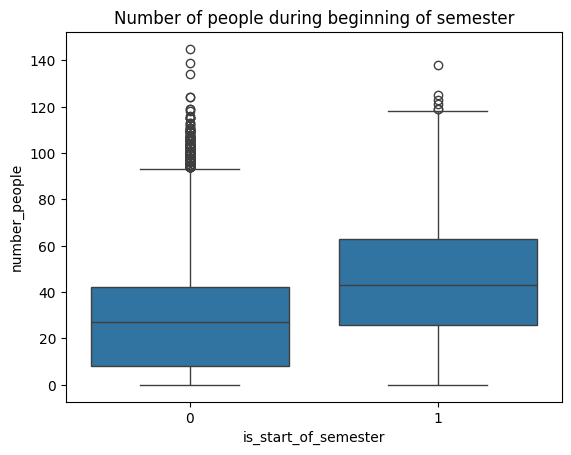

In [23]:
sns.boxplot(data=df, x="is_start_of_semester", y="number_people")
plt.title("Number of people during beginning of semester")
plt.show()

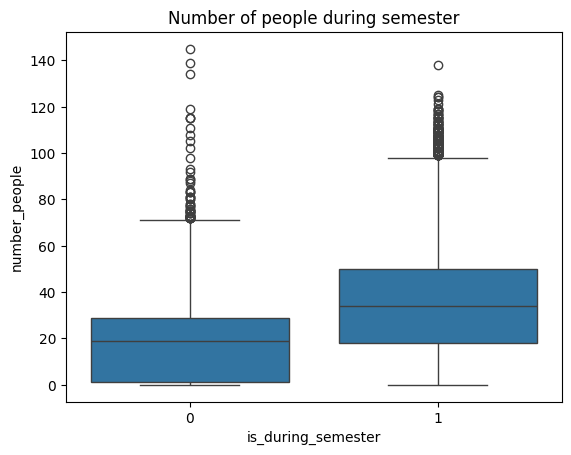

In [24]:
sns.boxplot(data=df, x="is_during_semester", y="number_people")
plt.title("Number of people during semester")
plt.show()

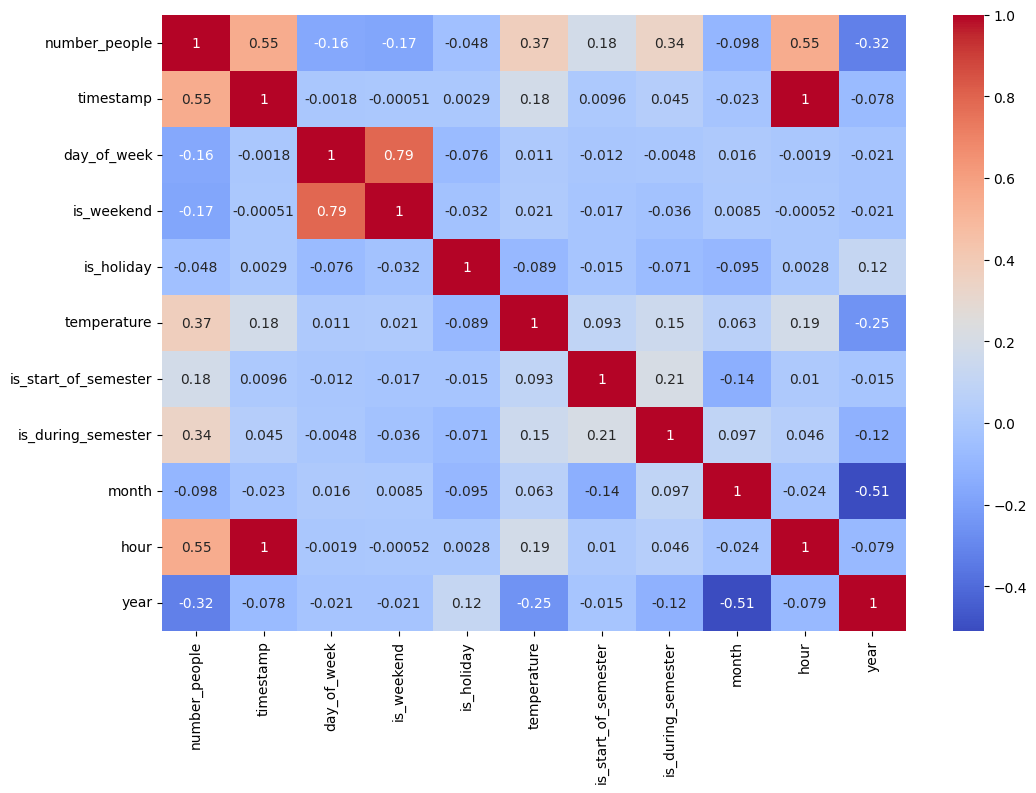

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [26]:
df.drop('timestamp', axis=1, inplace=True)

In [27]:
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


In [28]:
# dependent & independent feature
X = df.drop('number_people', axis=1)
y = df['number_people']

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [32]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [33]:
models = {
    "Lineer Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor()
}

In [34]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_predict = model.predict(X_train) 
    y_test_predict = model.predict(X_test)
    # İlk kez train predict yapıyoruz. Burada sonuçta eğer train predict ve test predict arasında çok fazla fark varsa overfitting olabilir 
    # bunu gözlemleyebiliriz.

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_predict) # tuple döndürecek!
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_predict)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("RMSE: ", model_train_rmse)
    print("MAE: ", model_train_mae)
    print("MSE: ", model_train_mse)
    print("R2 Score: ", model_train_r2)

    print("------------------------------------")

    print("Evaluation for Test Set")
    print("RMSE: ", model_test_rmse)
    print("MAE: ", model_test_mae)
    print("MSE: ", model_test_mse)
    print("R2 Score: ", model_test_r2)

    print("------------------------------------")
    print("\n")

LinearRegression()
Evaluation for Training Set
RMSE:  14.388343530259007
MAE:  10.766412453237272
MSE:  207.02442954474625
R2 Score:  0.5976993085646275
------------------------------------
Evaluation for Test Set
RMSE:  14.25258203374746
MAE:  10.665779345747854
MSE:  203.1360946287009
R2 Score:  0.6057850593875731
------------------------------------


Lasso()
Evaluation for Training Set
RMSE:  14.634389298117538
MAE:  10.966310250999484
MSE:  214.1653501288571
R2 Score:  0.5838226984718464
------------------------------------
Evaluation for Test Set
RMSE:  14.49629208996502
MAE:  10.88438150075566
MSE:  210.14248435758242
R2 Score:  0.5921881478395439
------------------------------------


Ridge()
Evaluation for Training Set
RMSE:  14.388343535919592
MAE:  10.766419710680768
MSE:  207.0244297076391
R2 Score:  0.5976993082480857
------------------------------------
Evaluation for Test Set
RMSE:  14.252579317050103
MAE:  10.665789767071326
MSE:  203.13601718880437
R2 Score:  0.6057852

In [35]:
# hyperparameter tuning

In [36]:
knn_params = {"n_neighbors" : [2,3,10,20,40,50]}
rf_params = {
    "n_estimators" : [100,200,500,100],
    "max_depth" : [5,8,10,15,None],
    "max_features" : ["sqrt", "log2", 5,7,10],
    "min_samples_split" : [2,8,12,20]
}

In [37]:
from sklearn.model_selection import RandomizedSearchCV

In [38]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RF", RandomForestRegressor(), rf_params)
]

In [39]:
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=100, cv=3, n_jobs=-1)
    randomcv.fit(X_train,y_train)
    print("Best params for: ", name, randomcv.best_params_)

Best params for:  KNN {'n_neighbors': 2}
Best params for:  RF {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 5, 'max_depth': None}


In [40]:
# Best params for:  KNN {'n_neighbors': 2}
#Best params for:  RF {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 10, 'max_depth': None}

In [41]:
models = {
    "K-Neighbors Regressor" : KNeighborsRegressor(n_neighbors=2,),
    "Random Forest Regressor" : RandomForestRegressor(n_estimators=500, min_samples_split=2, max_features=10,
                                                      max_depth= None)
}

In [42]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_predict = model.predict(X_train) 
    y_test_predict = model.predict(X_test)
    # İlk kez train predict yapıyoruz. Burada sonuçta eğer train predict ve test predict arasında çok fazla fark varsa overfitting olabilir 
    # bunu gözlemleyebiliriz.

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_predict) # tuple döndürecek!
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_predict)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("RMSE: ", model_train_rmse)
    print("MAE: ", model_train_mae)
    print("MSE: ", model_train_mse)
    print("R2 Score: ", model_train_r2)

    print("------------------------------------")

    print("Evaluation for Test Set")
    print("RMSE: ", model_test_rmse)
    print("MAE: ", model_test_mae)
    print("MSE: ", model_test_mse)
    print("R2 Score: ", model_test_r2)

    print("------------------------------------")
    print("\n")

KNeighborsRegressor(n_neighbors=2)
Evaluation for Training Set
RMSE:  5.467820241457277
MAE:  3.598953642952099
MSE:  29.89705819288992
R2 Score:  0.941902473976949
------------------------------------
Evaluation for Test Set
RMSE:  6.738660300655198
MAE:  4.54647497748617
MSE:  45.4095426476264
R2 Score:  0.9118762217478298
------------------------------------


RandomForestRegressor(max_features=10, n_estimators=500)
Evaluation for Training Set
RMSE:  4.748961941228854
MAE:  3.226369540972957
MSE:  22.552639519240127
R2 Score:  0.9561745321929652
------------------------------------
Evaluation for Test Set
RMSE:  6.242436266333347
MAE:  4.213011919648779
MSE:  38.968010539233816
R2 Score:  0.924376945472998
------------------------------------


